In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import nltk
from nltk.stem import WordNetLemmatizer
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [17]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhuwa\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\bhuwa\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhuwa\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [13]:
rmv_verb=WordNetLemmatizer()
def clean(text):
    text=text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text=re.sub(r'[^\w\s\t\n]',"",text)
    words=text.split()
    words=[rmv_verb.lemmatize(word,pos='v')for word in words]
    return " ".join(words)

In [ ]:
ds = load_dataset("milistu/AMAZON-Products-2023")
df=pd.DataFrame(ds['train'].select_columns(['title', 'description', 'main_category']))

In [18]:
df['title']=df['title'].apply(clean)
df['description']=df['description'].apply(clean)
df['main_category']=df['main_category'].str.lower()

In [19]:
df.head()

,title,description,main_category
0,anomie bonhomie,amazoncom fan of scritti polittis synthpopfunk...,digital music
1,sunshine on my shoulder the best of john denve...,sunshine on my shoulder be a 2cd 36track colle...,digital music
2,18 greatest hit of 38 special,track listings 1 rockin into the night 2 hold ...,digital music
3,the gift cd,second studio album by the multimillionselling...,digital music
4,τηε βοοτlεg sεrιεs vοι ᛐ7 ᛐ996ᛐ997 frαԍμεντտ τ...,eu edition 2cd disc one time out of mind 2022 ...,digital music


In [20]:
cmp_df=df[df['main_category'].notna()]
msng_df=df[df['main_category'].isna()]

In [21]:
cmp_df['text']=(cmp_df['title']+""+cmp_df['description'])

C:\Users\bhuwa\AppData\Local\Temp\ipykernel_11540\3121857896.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cmp_df['text']=(cmp_df['title']+""+cmp_df['description'])


In [54]:
vc = cmp_df['main_category'].value_counts()
cmp_df['main_category'] = cmp_df['main_category'].apply(
    lambda x: x if vc[x] >= 50 else "other")
x_train,x_test,y_train,y_test=train_test_split(cmp_df['text'],cmp_df['main_category'],test_size=0.2,random_state=42,stratify=cmp_df['main_category'])

In [61]:
lr_model=Pipeline([("cng_vctr",TfidfVectorizer(max_features=50000,ngram_range=(1,2),min_df=2,max_df=0.9,stop_words="english")),
                ('lr',LogisticRegression(max_iter=2000,class_weight="balanced"))])
nb_model=Pipeline([("cng_vctr",TfidfVectorizer(max_features=50000,ngram_range=(1,2),min_df=2,max_df=0.9,stop_words="english")),
                ('nb',MultinomialNB())])
svm_model=Pipeline([("cng_vctr",TfidfVectorizer(max_features=50000,ngram_range=(1,2),min_df=2,max_df=0.9,stop_words="english")),
                ('svm',LinearSVC(class_weight="balanced"))])

In [62]:
lr_model.fit(x_train,y_train)
nb_model.fit(x_train,y_train)
svm_model.fit(x_train,y_train)

Pipeline(steps=[('cng_vctr',
                 TfidfVectorizer(max_df=0.9, max_features=50000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('svm', LinearSVC(class_weight='balanced'))])

In [63]:
lr_pred=lr_model.predict(x_test)
nb_pred=nb_model.predict(x_test)
svm_pred=svm_model.predict(x_test)

In [64]:
print("...........lr_report............\n")
print(classification_report(y_test,lr_pred))


...........lr_report............

                           precision    recall  f1-score   support

               all beauty       0.10      0.38      0.16        13
          all electronics       0.76      0.75      0.76       627
           amazon fashion       0.97      0.89      0.93      7292
              amazon home       0.91      0.76      0.83      2775
               appliances       0.37      0.89      0.52        62
     appstore for android       0.67      0.79      0.72        28
    arts, crafts & sewing       0.46      0.81      0.58       175
               automotive       0.83      0.87      0.85      1196
           camera & photo       0.72      0.89      0.79       168
          car electronics       0.47      0.50      0.48        14
cell phones & accessories       0.91      0.87      0.89       694
  collectibles & fine art       1.00      0.91      0.95        23
                computers       0.86      0.88      0.87       345
            digital music  

In [65]:
print("\n\n..........nb_report...........\n")
print(classification_report(y_test,nb_pred))



..........nb_report...........



C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                           precision    recall  f1-score   support

               all beauty       0.00      0.00      0.00        13
          all electronics       0.64      0.71      0.67       627
           amazon fashion       0.88      0.98      0.93      7292
              amazon home       0.60      0.92      0.73      2775
               appliances       0.00      0.00      0.00        62
     appstore for android       0.00      0.00      0.00        28
    arts, crafts & sewing       0.94      0.17      0.28       175
               automotive       0.79      0.85      0.82      1196
           camera & photo       0.86      0.18      0.30       168
          car electronics       0.00      0.00      0.00        14
cell phones & accessories       0.88      0.86      0.87       694
  collectibles & fine art       1.00      0.04      0.08        23
                computers       0.91      0.73      0.81       345
            digital music       1.00      0.78      0.88     

C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
print("\n\n.........svm_report........\n")
print(classification_report(y_test,svm_pred))



.........svm_report........

                           precision    recall  f1-score   support

               all beauty       0.45      0.38      0.42        13
          all electronics       0.78      0.79      0.79       627
           amazon fashion       0.97      0.96      0.96      7292
              amazon home       0.90      0.85      0.87      2775
               appliances       0.51      0.76      0.61        62
     appstore for android       0.74      0.71      0.73        28
    arts, crafts & sewing       0.63      0.73      0.68       175
               automotive       0.84      0.89      0.86      1196
           camera & photo       0.78      0.87      0.82       168
          car electronics       0.64      0.50      0.56        14
cell phones & accessories       0.92      0.91      0.92       694
  collectibles & fine art       1.00      0.87      0.93        23
                computers       0.87      0.89      0.88       345
            digital music     

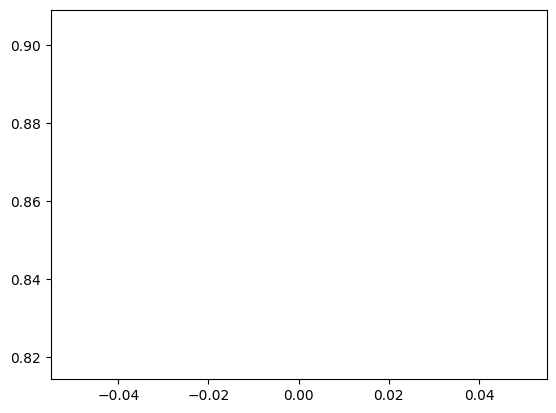